---
title: TRABAJO PRÁCTICO N° 3
subtitle: Clasificando pobres con la EPH
author: Ricardo Javier Gutiérrez Vistín - Martín Gabriel Cargnel
date-format: "MMM, YYYY"
lang: es
execute:
  echo: true
  include: false
  fig-align: center
format:
  pdf:
    documentclass: scrartcl
    toc-depth: 2
    number-sections: true
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split, GridSearchCV
from scipy.stats import ttest_ind

import statsmodels.api as sm
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, recall_score, roc_curve, roc_auc_score

Link al repositorio: https://github.com/mcargnel/Big-Data-UBA-Grupo-09/tree/main/TP3

{{< pagebreak >}}

In [2]:
respondieron = pd.read_parquet('/Users/mcargnel/Documents/mea/Big-Data-UBA-Grupo-001/TP3/data/respondieron.parquet')
norespondieron = pd.read_parquet('/Users/mcargnel/Documents/mea/Big-Data-UBA-Grupo-001/TP3/data/norespondieron.parquet')

In [3]:
respondieron_2025 = respondieron[respondieron['ano4'] == 2025].copy()
respondieron_2025 = respondieron_2025.reset_index(drop=True).drop(columns=['ano4'])
respondieron_2005 = respondieron[respondieron['ano4'] == 2005].copy()
respondieron_2005 = respondieron_2005.reset_index(drop=True).drop(columns=['ano4'])


norespondieron_2005 = norespondieron[norespondieron['ano4'] == 2005].copy()
norespondieron_2005 = norespondieron_2005.reset_index(drop=True).drop(columns=['ano4'])
norespondieron_2025 = norespondieron[norespondieron['ano4'] == 2025].copy()
norespondieron_2025 = norespondieron_2025.reset_index(drop=True).drop(columns=['ano4'])

# Enfoque de validación

En este ejercicio se buscará predecir la probabilidad de ser pobre dadas las siguientes variables: cantidad de horas trabajadas, hijos totales en el hogar, nivel educativo, edad y edad al cuadrado. Para ello se dividieron los datos entre los registros de 2005 y 2025, para después volver a dividir los datos de 2025 entre entrenamiento y testeo. Reservando el 70% de los datos para el entrenamiento. Es importante destacar que no hay diferencias significativas a ningún nivel de siginifcativadad estándar para las diferencias de las medias de las variables incluidas, lo cual es esperable por la asignación aleatoria a las muestras de entrenamiento y testeo.

In [4]:
X = respondieron_2025.drop(columns=['pobre'])
y = respondieron_2025['pobre']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 444)

In [6]:
ttest_results = ttest_ind(X_train, X_test)

df_stats_tidy = pd.DataFrame(
    data={
        'p-value': ttest_results.pvalue.round(2)
    },
    index=X_train.columns
).sort_values(by='p-value')

df_stats_tidy

,p-value
ix_tot,0.65
horastrab,0.84
educ,0.90
edad2,0.95
ch06,0.96


# Modelo de Regresión logística

El primer modelo que se utilizó fue una regresión logística, los resultados pueden verse en la @tab-reg-log donde se destaca la cantidad de hijos como el predictor que más afecta la probabilidad de ser pobre. Casi duplicandola. Luego, a destacar el nivel educativo que a medida aumenta se reduce la probabilidad de ser pobre. El resto de las variables no parecen tener demasiado efecto, pero las dos analizadas serían intuitivas.

In [7]:
X_sm = sm.add_constant(X_train) 
logit_model = sm.Logit(y_train, X_sm)
result = logit_model.fit()

coeficientes = result.params[1:]

# Calculamos los odds ratio
odds_ratio = np.exp(coeficientes)

# Guardamos el error estándar
std_error = result.bse[1:]  # Excluir el intercepto

# Creamos la tabla
tabla_resultados = pd.DataFrame({
    #'Variable': X.columns esta linea para cuando tengan muchas variables
    'Coeficiente': coeficientes,
    'Std. Error': std_error,
    'Odds Ratio': odds_ratio
})

Optimization terminated successfully.
         Current function value: 0.457198
         Iterations 7


In [8]:
#| label: tab-reg-log
#| tab-cap: Resultados de la regression logística.
#| echo: false
#| include: true

tabla_resultados.set_axis(['Edad', 'Edad2', 'Nivel Educativo', 'HorasTrab', 'Cant.Hijos']).round(2)

,Coeficiente,Std. Error,Odds Ratio
Edad,0.04,0.06,1.04
Edad2,-0.00,0.00,1.00
Nivel Educativo,-0.16,0.03,0.85
HorasTrab,0.00,0.00,1.00
Cant.Hijos,0.65,0.08,1.92


In [9]:
total_df = X_sm.copy()
total_df['prob'] = result.predict(X_sm)
total_df['y'] = y_train
total_df = total_df.sort_values('ix_tot')

Luego, en la @fig-prob-reg-log se puede ver la $\hat{P}(Y=1|X)$ para la cantidad de hijos por hogar. Se ve como claramente la probabilidad aumenta a medida que las familias tienen más hijos, sin embargo también se puede notar que pocas familias tiene más de 4 hijos.

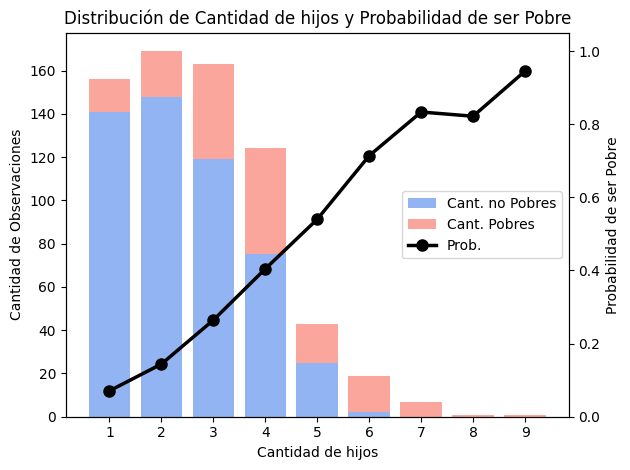

In [10]:
#| label: fig-prob-reg-log
#| fig-cap: Gráfico de la probabilidad de ser pobre calculada usando una regresión logística junto con la distribución de la cantidad de hijos en el hogar.
#| echo: false
#| include: true


counts_df = total_df.groupby('ix_tot')['y'].value_counts().unstack(fill_value=0)

prob_media_por_grupo = total_df.groupby('ix_tot')['prob'].mean()

fig, ax1 = plt.subplots()

ax1.bar(
    counts_df.index, 
    counts_df[0], 
    label='Cant. no Pobres', 
    color='cornflowerblue',
    alpha=0.7
)

ax1.bar(
    counts_df.index, 
    counts_df[1], 
    bottom=counts_df[0],
    label='Cant. Pobres', 
    color='salmon',
    alpha=0.7
)

ax1.set_xlabel("Cantidad de hijos")
ax1.set_ylabel("Cantidad de Observaciones")


ax2 = ax1.twinx()

ax2.plot(
    prob_media_por_grupo.index, 
    prob_media_por_grupo.values, 
    label='Prob.', 
    color='black',
    marker='o',
    linewidth=2.5,
    markersize=8
)

ax2.set_ylabel("Probabilidad de ser Pobre", color='black')
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis='y', labelcolor='black')

ax1.set_title("Distribución de Cantidad de hijos y Probabilidad de ser Pobre")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

handles_totales = h1 + h2
labels_totales = l1 + l2


ax1.legend(
    handles=handles_totales, 
    labels=labels_totales, 
    loc='right',
    fontsize='medium'
)

ax1.set_xticks(prob_media_por_grupo.index)

fig.tight_layout()

plt.show()

# Método de Vecinos Cercanos (KNN)

El segundo modelo implementado fue el de vecinos más cercanos (KNN). Este algoritmo se caracteriza por el hiperparámetro $k$, el cual denota cuántos "vecinos" se consideran para realizar la estimación.

Como se observa en la @fig-acc-knn, a medida que k aumenta, la accuracy de entrenamiento disminuye, mientras que la de testeo mejora, aunque generalmente solo hasta un punto óptimo. Este comportamiento es esperable y refleja el clásico equilibrio (trade-off) entre sesgo y varianza. Un valor de k pequeño (ej. k=1) genera un modelo de alta varianza, ya que la predicción depende de muy pocos puntos y es muy sensible al ruido. Por el contrario, un valor de k mayor reduce la varianza (la predicción se estabiliza al promediar más observaciones) pero incrementa el sesgo (el modelo se vuelve menos flexible y puede "sub-ajustar" los datos, perdiendo patrones locales).

In [11]:
k_range = [1, 5, 10, 20]
scores = {}
scores_list_train = []
scores_list_test = []
for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)
        
        y_pred_knn_train = knn.predict(X_train)
        scores[k] = accuracy_score(y_train, y_pred_knn_train)
        scores_list_train.append(accuracy_score(y_train, y_pred_knn_train))

        y_pred_knn_test = knn.predict(X_test)
        scores[k] = accuracy_score(y_test, y_pred_knn_test)
        scores_list_test.append(accuracy_score(y_test, y_pred_knn_test))

Text(0.5, 1.0, 'Gráfico del Accuracy para distintos valores de K')

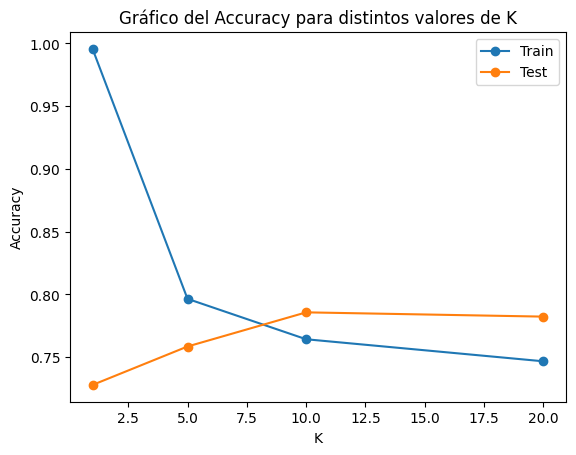

In [12]:
#| label: fig-acc-knn
#| fig-cap: Gráfico con la accuracy para distintos valores de K. Se ve claramente como aumentar el valor de K hace que el modelo generalice mejor en la muestra de testeo.
#| echo: false
#| include: true

fig, ax = plt.subplots()

ax.plot(k_range, scores_list_train, label='Train', marker = 'o')
ax.plot(k_range, scores_list_test, label='Test', marker = 'o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Gráfico del Accuracy para distintos valores de K')

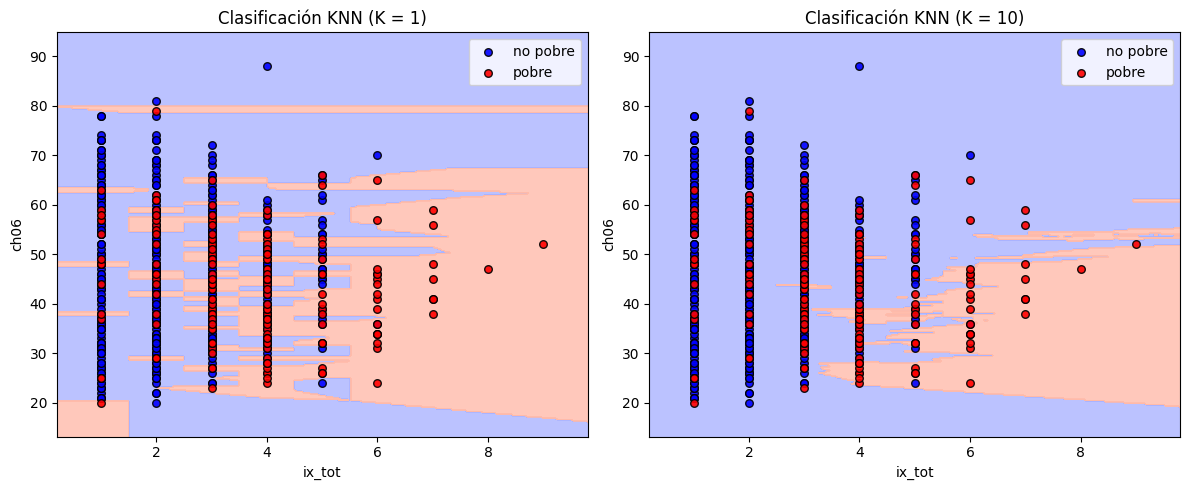

In [13]:
#| label: fig-knn-fronteras
#| fig-cap: Gráfico de con las fronteras de clasificación para KNN.
#| echo: false
#| include: true

X_train_2d = X_train[['ix_tot', 'ch06']]

K_list = (1, 10)

colors_light = ['#AAb3FF', '#FFBBAA']
colors_bold = ['blue', 'red']
cmap_light = ListedColormap(colors_light)

n_plots = len(K_list)
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))

if n_plots == 1:
    axes = [axes]

X_data = X_train_2d.values

pad_x = (X_data[:, 0].max() - X_data[:, 0].min()) * 0.1
pad_y = (X_data[:, 1].max() - X_data[:, 1].min()) * 0.1

if pad_x == 0: pad_x = 1
if pad_y == 0: pad_y = 1

x_min, x_max = X_data[:, 0].min() - pad_x, X_data[:, 0].max() + pad_x
y_min, y_max = X_data[:, 1].min() - pad_y, X_data[:, 1].max() + pad_y

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

for i, k in enumerate(K_list):
    ax = axes[i]

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_data, y_train) # <-- Usando X_data

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

    for i_class, label in enumerate(['no pobre', 'pobre']):
        mask = (y_train == i_class)

        ax.scatter(X_data[mask, 0], X_data[mask, 1], 
                    c=colors_bold[i_class],
                    label=label,
                    edgecolor='k', s=30, alpha=0.9)

    ax.set_title(f"Clasificación KNN (K = {k})")
    ax.set_xlabel(X_train_2d.columns[0])
    ax.set_ylabel(X_train_2d.columns[1])
    ax.legend(loc='best')

plt.tight_layout()
plt.show()

Para elegir el $K$ óptimo se utilizó la técnica de cross-validation. Los resultados pueden verse en la @fig-knn-kfold donde queda claro que K=4 maximiza la accuracy. Por lo que será utilizado para evaluarlo en la muestra de testeo.

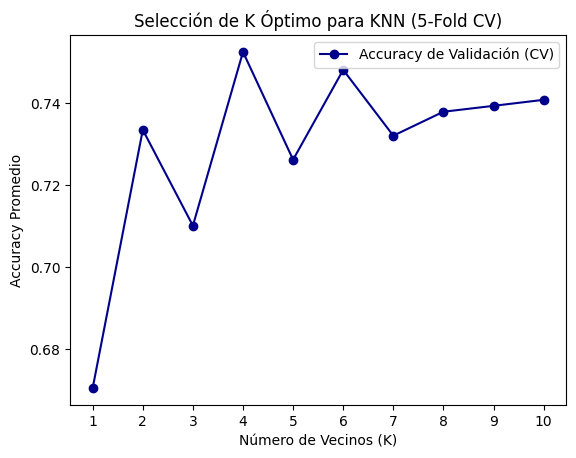

In [14]:
#| label: fig-knn-kfold
#| fig-cap: Gráfico con resultados de cross validation con k = 5.
#| echo: false
#| include: true

k_range = range(1, 11)

param_grid = {
    'n_neighbors': k_range  
}

knn = KNeighborsClassifier()

grid_search_knn = GridSearchCV(
    estimator=knn,          
    param_grid=param_grid,
    cv=5,                 
    scoring='accuracy',   
    return_train_score=True
)

grid_search_knn.fit(X_train, y_train)

mean_test_scores = grid_search_knn.cv_results_['mean_test_score']

plt.figure()
plt.plot(k_range, mean_test_scores, 'o-', color='darkblue', label='Accuracy de Validación (CV)')
plt.title('Selección de K Óptimo para KNN (5-Fold CV)')
plt.xlabel('Número de Vecinos (K)')
plt.ylabel('Accuracy Promedio')
plt.xticks(k_range) # Asegura que veamos todos los K en el eje X
plt.legend()
plt.show()

In [15]:
knn_final = KNeighborsClassifier(n_neighbors=4)
knn_final.fit(X_train, y_train)

,n_neighbors,4
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# Desempeño de modelos afuera de la muestra, métricas y politicas públicas

Habiendo entrenado ambos modelos en la muestra de entrenamiento, toca ver su performance en la muestra de testeo. En la @tab-conf-matrix puede verse la matriz de confusión para la regresión logística en los datos de testeo. Vemos que hay 54 observaciones mal clasificadas, siendo más las que se predicieron como pobre las que no son.

Para comparar los dos modelos puede usarse la @fig-roc-curve y @tab-metrics, en ambas se ve como la regresión logística supera a KNN. En particular, sin analizamos el recall de la tabla parecería que el modelo KNN estaría prediciendo casi todas las observaciones como no-pobres, por ser esta la clase mayoritaria. Por lo que a nivel política publica recomendaría utilizar la regresión logística en lugar de KNN. Cabe aclarar que utilizar este modelo presenta una ventaja adicional: al ser un modelo más simple y no requerir hiperparametros es más usualmente más sencillo de poner en producción. Algo siempre deseable.

In [16]:
X_sm_test = sm.add_constant(X_test)

In [17]:
pred_reg_log = result.predict(sm.add_constant(X_test))
pobre_log = np.where(pred_reg_log > 0.5, 1, 0)
pred_knn = knn_final.predict_proba(X_test)[:, 1] 
pobre_knn = knn_final.predict(X_test)

In [18]:
#| label: tab-conf-matrix
#| tab-cap: Tabla de confusion para la regresión logística.
#| echo: false
#| include: true

# Matriz de confusion
pd.crosstab(index=y_test, columns=pobre_log).rename(columns={0:'Pred: No Pobre', 1:'Pred: Pobre'})

col_0,Pred: No Pobre,Pred: Pobre
pobre,,
0,215,15
1,39,25


Finalmente, se utilizó la regresión logística para predecir a aquellos que NO respondieron la encuesta y, pese a no tener el resultado final, la proporción de personas que no respondrieron indentificada como pobres es del ~31%.

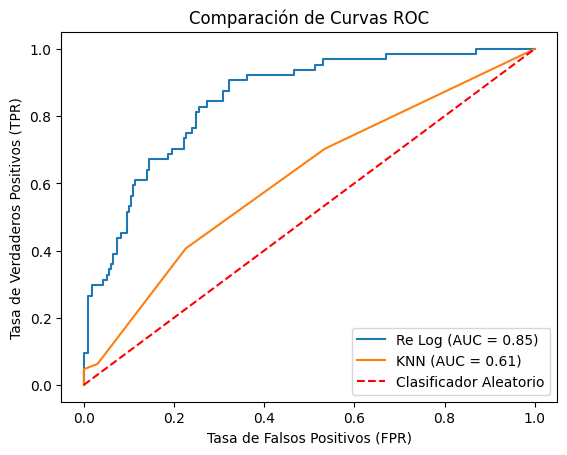

In [19]:
#| label: fig-roc-curve
#| fig-cap: Gráfico con curvas ROC para regresión logística y KNN.
#| echo: false
#| include: true

fpr_log, tpr_log, _ = roc_curve(y_test, pred_reg_log)
auc_log = roc_auc_score(y_test, pred_reg_log)

fpr_knn, tpr_knn, _ = roc_curve(y_test, pred_knn)
auc_knn = roc_auc_score(y_test,pred_knn)

plt.figure()

plt.plot(fpr_log, tpr_log, label=f'Re Log (AUC = {auc_log:.2f})')

plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')

plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Clasificador Aleatorio')

plt.title('Comparación de Curvas ROC')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend()

plt.show()

In [20]:
#| label: tab-metrics
#| tab-cap: Tabla con accuracy y recall para en la muestra de testeo para la regresión logística y KNN.
#| echo: false
#| include: true

metricas = {
    'Reg Log': [
        accuracy_score(y_test, pobre_log),
        recall_score(y_test, pobre_log)
    ],
    'KNN': [
        accuracy_score(y_test, pobre_knn),
        recall_score(y_test, pobre_knn)
    ]
}

df_resultados = pd.DataFrame(metricas, index=['Accuracy', 'Recall'])
df_resultados

,Reg Log,KNN
Accuracy,0.816327,0.772109
Recall,0.390625,0.062500


Finalmente, se utilizó la regresión logística para predecir a aquellos que NO respondieron la encuesta y, pese a no tener el resultado final, la proporción de personas que no respondrieron indentificada como pobres es del ~31%.

In [21]:
respondieron_2025['pobre'].mean()

np.float64(0.24257932446264074)

In [22]:
result.predict(sm.add_constant(norespondieron_2025)).mean()

np.float64(0.30690562702084695)